In [4]:
import numpy as np
import matplotlib.pyplot as plt

Initialisation des constantes

In [5]:
R_gen = 1.0 #ohm
R_mot = 1.0 #ohm
phi_0 = 0.06 #Wb (constante conservée)
U_ent = np.array([7.15, 13.41, 16.48, 21.19]) #V
I_ent = np.array([1.26, 1.68, 1.83, 2.13]) #A
U_sort = np.array([5.35, 10.45, 12.99, 16.69]) #V
I_sort = np.array([0.238, 0.469, 0.582, 0.750]) #A
Omega = np.array([889, 1760, 2196, 2845]) #tr/min
P_e = np.array([8.9, 22.6, 30.0, 45.1]) # W
P_s = np.array([1.26, 4.9, 7.59, 12.52]) # W

R_mes_int = 1.013    #ohm 
Pperte_tot = P_e - P_s # W
P_cuiv_mot = R_mot * I_ent**2 # W
P_cuiv_gen = R_gen * I_sort**2 # W
P_perte_meca = Pperte_tot - P_cuiv_mot - P_cuiv_gen # W
efficiency = P_s / P_e 
couple_utile = ((U_sort * I_sort)+R_gen * I_sort**2 + P_perte_meca/2) / (Omega * (2 * np.pi / 60)) # Nm

Calculs des pertes méca en fonction de la vitesse de rotation

Text(0.5, 1.0, 'Puissance mécanique perdue en fonction de la vitesse de rotation')

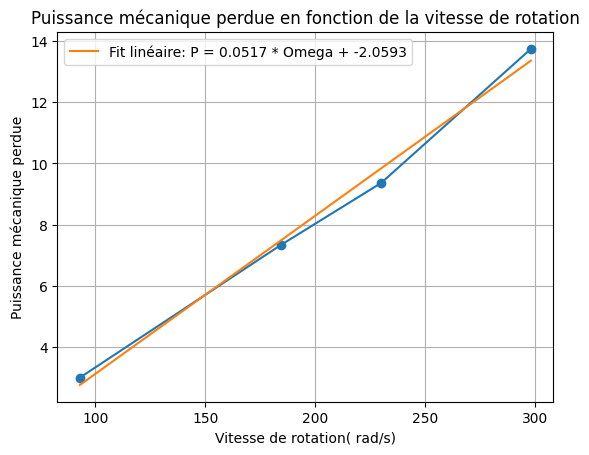

In [6]:
plt.plot(Omega*2*np.pi/60, P_perte_meca/2, marker='o')
coeffs = np.polyfit(Omega*2*np.pi/60, P_perte_meca/2, 1)
plt.plot(Omega*2*np.pi/60, np.polyval(coeffs, Omega*2*np.pi/60), label=f'Fit linéaire: P = {coeffs[0]:.4f} * Omega + {coeffs[1]:.4f}')
plt.legend()
plt.grid()
plt.xlabel("Vitesse de rotation( rad/s)")
plt.ylabel("Puissance mécanique perdue")
plt.title("Puissance mécanique perdue en fonction de la vitesse de rotation")

In [7]:
def P_meca_1_mot(Omega):
    return (coeffs[0] * Omega + coeffs[1])

In [8]:
T1,I_mes,T2,V_mes = np.loadtxt("24V_div4_n3.csv", delimiter=";",skiprows=1, unpack=True)
I1 = I_mes*R_mes_int
V1 = V_mes*2 #coeff division par 2

In [9]:
## fonction lissage : retourne un tableau correspondant aux valeurs de signal_brut remplacées par une moyenne glissante, des valeurs qui les entourent, centrée de largeur deux L
def lisser(signal_brut,L):
    res = np.copy(signal_brut) # duplication des valeurs
    for i in range (1,len(signal_brut)-1): # toutes les valeurs sauf la première et la dernière
        L_g = min(i,L) # nombre de valeurs disponibles à gauche
        L_d = min(len(signal_brut)-i-1,L) # nombre de valeurs disponibles à droite
        Li=min(L_g,L_d)
        res[i]=np.sum(signal_brut[i-Li:i+Li+1])/(2*Li+1)
    return res

In [10]:

#n=1150 #12_3V_1 (div par 2).csv
n=len(T2) #24V_div4_n2.csv


Tension_liss_1 = lisser(V1[:n],40)
Tension_liss_2 = lisser(V1[n:],40)
Tension_liss = np.concatenate((Tension_liss_1,Tension_liss_2))

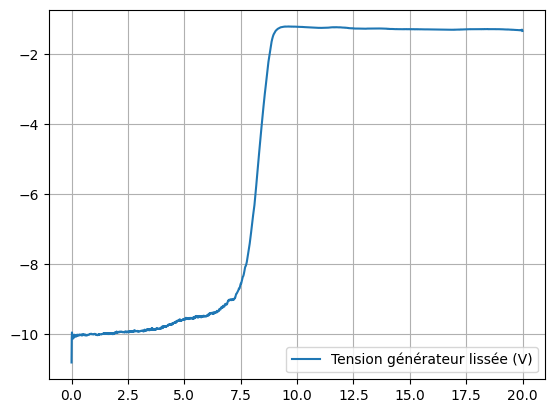

In [11]:
plt.plot(T2, Tension_liss, label='Tension générateur lissée (V)')
plt.legend()
plt.grid()

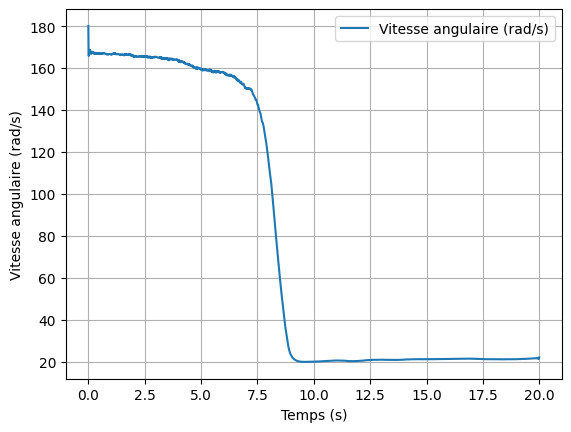

In [12]:
Omega = np.abs(Tension_liss / phi_0)
plt.plot(T2, Omega, label='Vitesse angulaire (rad/s)')
plt.xlabel('Temps (s)')
plt.ylabel('Vitesse angulaire (rad/s)')
plt.grid()
plt.legend()

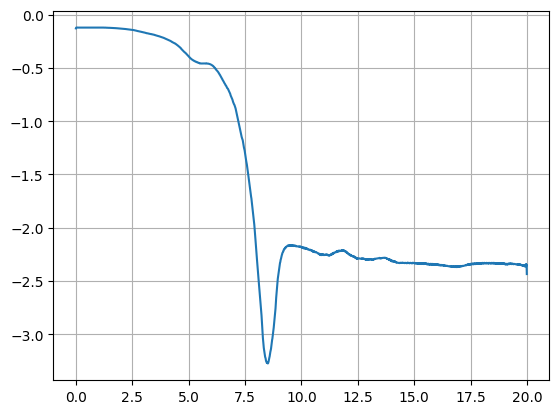

In [13]:
Intensite_liss_1 = lisser(I1[:n],30)
Intensite_liss_2 = lisser(I1[n:],30)
Intensite_liss = np.concatenate((Intensite_liss_1, Intensite_liss_2))
plt.plot(T2, Intensite_liss, label='Courant générateur lissé (A)')
plt.grid()

In [14]:
P_perte_meca

array([ 5.995756, 14.657639, 18.722376, 27.4806  ])

Text(0.5, 1.0, 'Couple en fonction du temps (S3)')

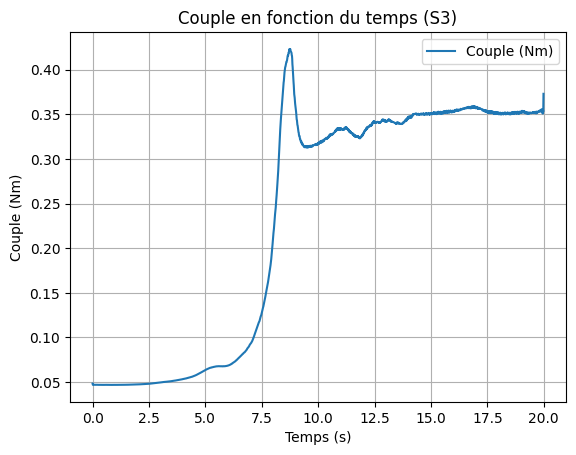

In [15]:
Cpl = ((Tension_liss * Intensite_liss)+R_gen * Intensite_liss**2 + P_meca_1_mot(Omega)) / (Omega)
plt.plot(T2, Cpl, label='Couple (Nm)')

plt.grid()
plt.legend()
plt.xlabel('Temps (s)')
plt.ylabel('Couple (Nm)')
plt.title('Couple en fonction du temps (S3)')

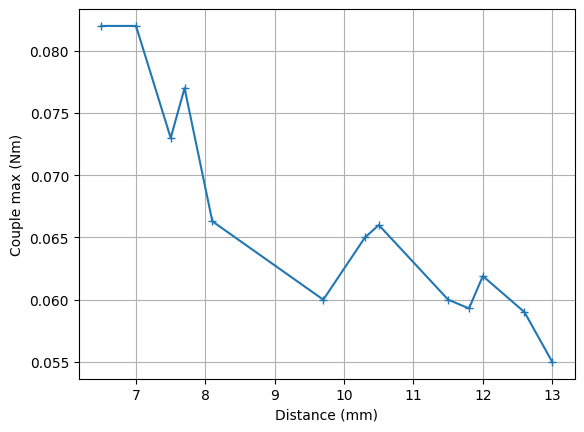

In [16]:
#d = [6.5 ,7, 7.5,7.7,8,8.1,8.9, 9.5, 9.7,10.3, 10.5, 11.5, 11.8, 12, 12.6, 13.] # mm
#C_max = [0.082, 0.082, 0.073,0.077,0.097,0.0663, 0.084, 0.0879,0.06, 0.065,0.066, 0.06,0.0593, 0.0619, 0.059, 0.055] # Nm
d = [6.5 ,7, 7.5,7.7,8.1,9.7,10.3, 10.5, 11.5, 11.8, 12, 12.6, 13.] # mm
C_max = [0.082, 0.082, 0.073,0.077,0.0663, 0.06, 0.065,0.066, 0.06,0.0593, 0.0619, 0.059, 0.055] # Nm
plt.plot(d, C_max, '+-', label='Couple max en fonction de la distance (Nm)')
plt.xlabel('Distance (mm)')
plt.ylabel('Couple max (Nm)')
plt.grid()